In [33]:
# load necessary libraries 
import scanpy as sc
import matplotlib.pyplot as plt
import anndata as ad
import pandas as pd
import numpy as np
import gseapy as gp

In [34]:
# load data (preprocessed from 'preprocessing.py')
adata = sc.read_h5ad("../data/frangieh/adata_preprocessed.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 190804 × 23711
    obs: 'library_preparation_protocol', 'condition', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'n_counts', 'doublet_scores', 'predicted_doublets', 'doublet_info'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells',

# Selection of 50 pertubations 
To compare model generalizability, we select 50 perturbations using five distinct strategies:
* a) 50 most frequent pertubations 
* b) 50 randomly selected pertubations 
* c) 50 pertubations with highest LFC 
* d) cluster pertubations and select pertubations from each cluster -> most different 
* e) greedy algorithm: select 50 pertubations which exist in different pathways 


In [35]:
pertubation_counts = adata.obs[adata.obs['perturbation'] != 'control']['perturbation'].value_counts()
print(pertubation_counts)

# (a) 50 most frequent pertubations
top50_pertubations = pertubation_counts.head(50).index.tolist()

# (b) 50 randomly selected pertubations
np.random.seed(42)
all_pertubations = pertubation_counts.index.tolist()
random50_pertubations = list(np.random.choice(all_pertubations, size=50, replace=False))

perturbation
ACTA2      1215
B2M        1145
IFNGR2     1094
A2M        1092
AEBP1      1086
           ... 
AHCY         77
SNRPG        72
FARSA        65
RUVBL2       58
control       0
Name: count, Length: 238, dtype: int64


In [36]:
## (c) Aggregating across all three conditions by taking the maximum mean absolute LFC per pertubation
# calculate pseudo-bulk: mean profile per pertubation group
pertubation_bulk_adata = sc.get.aggregate(adata, by=['condition', 'perturbation'], func='mean', layer = "counts")
pertubation_bulk_adata.X = pertubation_bulk_adata.layers['mean'].copy()

df_expr = pertubation_bulk_adata.to_df()
df_obs = pertubation_bulk_adata.obs

In [37]:
# calculate lfc 
eps = 1

df_log_expr = np.log2(df_expr + eps)

ctrl_rows = df_obs[df_obs['perturbation'] == 'control'] # per condition unperturbed cells

# mean gene expression from control cells (no pertubation)
ctrl_control = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Control'].index].mean()
ctrl_IFN_gamma = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'IFNγ'].index].mean()
ctrl_co_culture = df_log_expr.loc[ctrl_rows[ctrl_rows['condition'] == 'Co-culture'].index].mean()

# get cells with pertubations 
non_ctrl_obs = df_obs[df_obs['perturbation'] != 'control'].copy()
non_ctrl_lfc = df_log_expr.loc[non_ctrl_obs.index].copy()

# substracting baseline condition profile from expression of knockout per condition
for idx in non_ctrl_obs.index:
    condition = non_ctrl_obs.loc[idx, 'condition']
    if condition == 'Control':
        non_ctrl_lfc.loc[idx] -= ctrl_control
    elif condition == 'IFNγ':
        non_ctrl_lfc.loc[idx] -= ctrl_IFN_gamma
    elif condition == 'Co-culture':
        non_ctrl_lfc.loc[idx] -= ctrl_co_culture

log_fold_change_adata = ad.AnnData(X=non_ctrl_lfc.values, obs=non_ctrl_obs, var=pertubation_bulk_adata.var.copy())    

# filter for HVGs 
log_fold_change_adata_hvg = log_fold_change_adata[:, log_fold_change_adata.var['highly_variable']].copy()

In [38]:
# (c) selection of 50 pertubations according to their highest LFC 

# mean absolute LFC over all 2000 genes per row 
df_lfc_all = log_fold_change_adata_hvg.to_df()
df_lfc_all['perturbation'] = log_fold_change_adata_hvg.obs['perturbation'].values
df_lfc_all['mean_abs_lfc'] = df_lfc_all.drop(columns='perturbation').abs().mean(axis=1)

# maximal LFC per pertubation over all 3 conditions  
pert_strength = df_lfc_all.groupby('perturbation')['mean_abs_lfc'].max()

# top 50 pertubations with strongest total effect
top_lfc50_pertubations = pert_strength.sort_values(ascending=False).head(50).index.tolist()

/tmp/ipykernel_9278/432277892.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pert_strength = df_lfc_all.groupby('perturbation')['mean_abs_lfc'].max()


In [39]:
## (d) cluster pertubations and select pertubations from each cluster -> most different 
# PCA over all conditions: connect LFC profiles of the 3 conditions per row 
conds = ['Control', 'IFNγ', 'Co-culture']
dfs = []

for cond in conds:
    mask = log_fold_change_adata_hvg.obs['condition'] == cond
    sub_df = log_fold_change_adata_hvg[mask].to_df()
    sub_df.index = log_fold_change_adata_hvg[mask].obs['perturbation'].values
    sub_df = sub_df.add_suffix(f"_{cond}")
    dfs.append(sub_df)

# Matrix: 245 Knockouts (rows) and 6000 LFC-Features (cols)
df_lfc_all_conds = pd.concat(dfs, axis=1)

adata_perts_combined = ad.AnnData(
    X=df_lfc_all_conds.values,
    obs=pd.DataFrame(
        {'perturbation': df_lfc_all_conds.index}, index=df_lfc_all_conds.index
    ),
    var=pd.DataFrame(index=df_lfc_all_conds.columns),
)


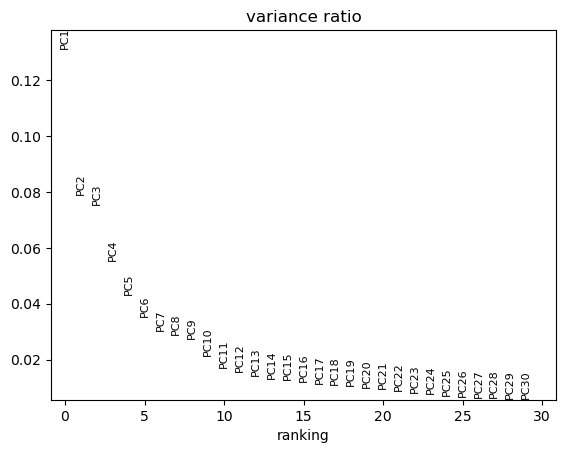

In [40]:
# PCA 
sc.pp.pca(adata_perts_combined, n_comps=30)
sc.pl.pca_variance_ratio(adata_perts_combined, n_pcs=30, log=False)

In [41]:
# select 8 PCs
sc.pp.neighbors(adata_perts_combined, n_pcs=8)
sc.tl.leiden(adata_perts_combined, resolution=0.6, flavor='igraph', directed=False)
sc.tl.umap(adata_perts_combined)

In [42]:
# select 50 pertubations 
np.random.seed(42)

cluster_series = adata_perts_combined.obs['leiden']
n_clusters = cluster_series.nunique()
samples_per_cluster = int(np.ceil(50 / n_clusters))

cluster50_pertubations = []
for cluster_id in sorted(cluster_series.unique()):
    cluster_perts = cluster_series[cluster_series == cluster_id].index.tolist()
    n_sample = min(samples_per_cluster, len(cluster_perts))
    chosen = np.random.choice(
        cluster_perts, size=n_sample, replace=False
    ).tolist()
    cluster50_pertubations.extend(chosen)
    print(
        f'Cluster {cluster_id}: {len(chosen)} / {len(cluster_perts)} genes'
        ' selected'
    )

# fill to 50 genes, if one cluster has less than 10 genes
if len(cluster50_pertubations) > 50:
    cluster50_pertubations = np.random.choice(
        cluster50_pertubations, size=50, replace=False
    ).tolist()
elif len(cluster50_pertubations) < 50:
    remaining = [
        p
        for p in adata_perts_combined.obs['perturbation']
        if p not in cluster50_pertubations
    ]
    needed = 50 - len(cluster50_pertubations)
    cluster50_pertubations.extend(
        np.random.choice(remaining, size=needed, replace=False).tolist()
    )

print(
    f'\ntotal selected pertubations:'
    f' {len(cluster50_pertubations)}'
)

Cluster 0: 10 / 45 genes selected
Cluster 1: 10 / 51 genes selected
Cluster 2: 10 / 71 genes selected
Cluster 3: 10 / 65 genes selected
Cluster 4: 5 / 5 genes selected

total selected pertubations: 50


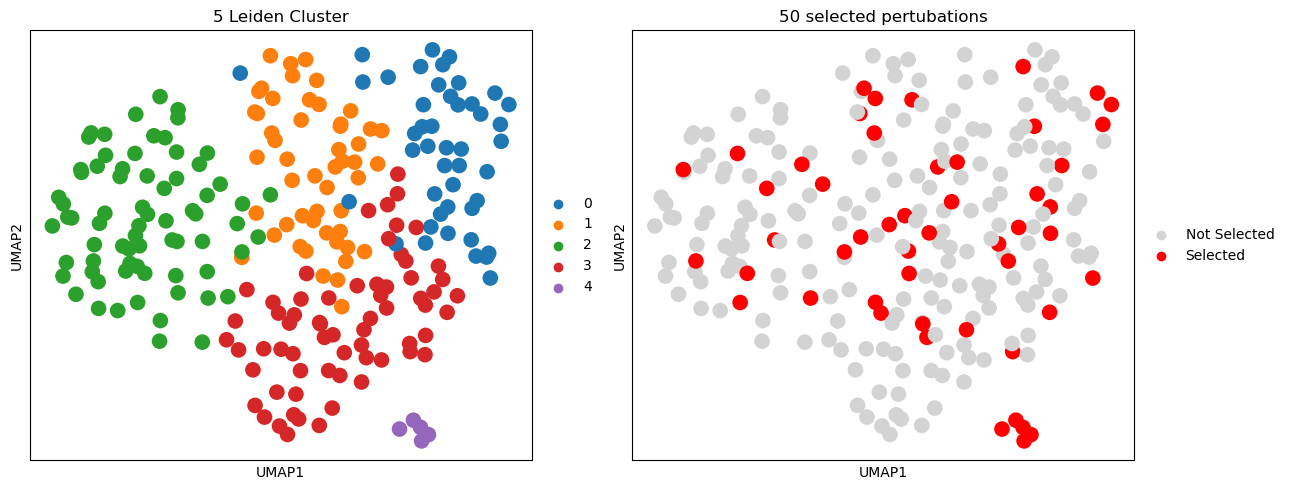

In [43]:
# visualization 
adata_perts_combined.obs['selected_50'] = adata_perts_combined.obs[
    'perturbation'
].apply(lambda x: 'Selected' if x in cluster50_pertubations else 'Not Selected')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sc.pl.umap(
    adata_perts_combined,
    color='leiden',
    ax=ax1,
    show=False,
    title=f'{n_clusters} Leiden Cluster',
)
sc.pl.umap(
    adata_perts_combined,
    color='selected_50',
    palette={'Selected': 'red', 'Not Selected': 'lightgrey'},
    ax=ax2,
    show=False,
    title='50 selected pertubations',
)
plt.tight_layout()
plt.show()

In [44]:
## (e) greedy algorithm: select 50 pertubations which exist in different pathways 
# load hallmark pathways 
hallmark = gp.get_library(name="MSigDB_Hallmark_2020", organism="Human")

hallmark_upper = {pathway: {str(g).upper() for g in genes} for pathway, genes in hallmark.items()}

In [45]:
eligible_genes = all_pertubations

pathway_matrix = pd.DataFrame(0, index=eligible_genes, columns=hallmark_upper.keys(), dtype=int)
for gene in eligible_genes:
    g_up = str(gene).upper()
    for pathway, p_genes in hallmark_upper.items():
        if g_up in p_genes:
            pathway_matrix.loc[gene, pathway] = 1


In [46]:
rng = np.random.default_rng(42)
annotated_genes = pathway_matrix.index[pathway_matrix.sum(axis=1) > 0].tolist()

pathway50_pertubations = []
covered_pathways = set()
remaining = annotated_genes.copy()

while len(pathway50_pertubations) < 50 and len(remaining) > 0:
    gains = {}
    for gene in remaining:
        gene_pathways = set(pathway_matrix.columns[pathway_matrix.loc[gene] == 1])
        new_pathways = gene_pathways - covered_pathways
        gains[gene] = len(new_pathways)
        
    max_gain = max(gains.values())
    
    # if no gene is found in a new pathway, stop loop
    if max_gain == 0:
        break
        
    best_genes = [g for g, gain in gains.items() if gain == max_gain]
    chosen = rng.choice(best_genes)
    
    pathway50_pertubations.append(chosen)
    covered_pathways.update(pathway_matrix.columns[pathway_matrix.loc[chosen] == 1])
    remaining.remove(chosen)

# if < 50 Gene: fill with remaining genes
if len(pathway50_pertubations) < 50:
    extra_candidates = [g for g in eligible_genes if g not in pathway50_pertubations]
    extra = rng.choice(extra_candidates, size=50 - len(pathway50_pertubations), replace=False)
    pathway50_pertubations.extend(extra.tolist())

print(f"selected genes: {len(pathway50_pertubations)}")
print(f"covered Hallmark-pathways: {pathway_matrix.loc[pathway50_pertubations].max(axis=0).sum()} / 50")


selected genes: 50
covered Hallmark-pathways: 46 / 50


In [49]:
# save data 
log_fold_change_adata_hvg.uns['subsets'] = {
    'random': random50_pertubations,
    'essentiality': top50_pertubations,
    'highest_lfc': top_lfc50_pertubations,
    'leiden_clusters': cluster50_pertubations,
    'hallmark_pathways': pathway50_pertubations,
}

log_fold_change_adata_hvg.write_h5ad('../data/frangieh/log_fold_change_adata_hvg.h5ad')
